# 🧠 TMS2 - LSTM Traffic Prediction Training

Train multiple LSTM architectures for traffic prediction:
- **Standard LSTM**
- **Bidirectional LSTM**
- **Attention LSTM**
- **Transformer-LSTM Hybrid**

---

## 1. Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/tms2_colab_training'
DATA_PATH = f'{DRIVE_PATH}/data/lstm_ready'
MODEL_PATH = f'{DRIVE_PATH}/models'

import os
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(f'{MODEL_PATH}/checkpoints', exist_ok=True)

print(f"Working directory: {DRIVE_PATH}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/tms2_colab_training


In [2]:
# Check GPU
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available! Training will be fast.")
else:
    print("⚠️ No GPU found. Go to Runtime > Change runtime type > GPU")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is available! Training will be fast.


In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional,
    LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)

print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

In [4]:
# Load pre-processed LSTM data
X = np.load(f'{DATA_PATH}/X_sequences.npy')
y = np.load(f'{DATA_PATH}/y_targets.npy')

with open(f'{DATA_PATH}/feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
with open(f'{DATA_PATH}/target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

print(f"Data loaded:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

SEQUENCE_LENGTH = X.shape[1]
N_FEATURES = X.shape[2]
print(f"\nSequence length: {SEQUENCE_LENGTH}")
print(f"Number of features: {N_FEATURES}")

Data loaded:
  X shape: (66243, 15, 5)
  y shape: (66243,)

Sequence length: 15
Number of features: 5


In [5]:
# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 46370 samples
Validation set: 9936 samples
Test set: 9937 samples


## 3. Model Architectures

In [6]:
def build_standard_lstm(seq_len, n_features, hidden_units=[128, 64], dropout=0.2):
    """Standard LSTM model."""
    model = Sequential([
        LSTM(hidden_units[0], return_sequences=True,
             input_shape=(seq_len, n_features)),
        Dropout(dropout),
        LSTM(hidden_units[1], return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model


def build_bidirectional_lstm(seq_len, n_features, hidden_units=[128, 64], dropout=0.2):
    """Bidirectional LSTM for capturing past and future context."""
    model = Sequential([
        Bidirectional(LSTM(hidden_units[0], return_sequences=True),
                     input_shape=(seq_len, n_features)),
        Dropout(dropout),
        Bidirectional(LSTM(hidden_units[1], return_sequences=False)),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model


def build_attention_lstm(seq_len, n_features, hidden_units=128, dropout=0.2):
    """LSTM with attention mechanism."""
    inputs = Input(shape=(seq_len, n_features))

    # LSTM layer
    lstm_out = LSTM(hidden_units, return_sequences=True)(inputs)
    lstm_out = Dropout(dropout)(lstm_out)

    # Self-attention
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_out, lstm_out)
    attention = Dropout(dropout)(attention)

    # Add & Norm
    x = LayerNormalization()(lstm_out + attention)

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    # Dense layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model


def build_transformer_lstm(seq_len, n_features, hidden_units=128, num_heads=4, dropout=0.2):
    """Hybrid Transformer-LSTM architecture."""
    inputs = Input(shape=(seq_len, n_features))

    # Initial LSTM encoding
    x = LSTM(hidden_units, return_sequences=True)(inputs)
    x = LayerNormalization()(x)

    # Transformer block
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=32)(x, x)
    attention = Dropout(dropout)(attention)
    x = LayerNormalization()(x + attention)

    # Feed-forward
    ff = Dense(hidden_units * 2, activation='relu')(x)
    ff = Dense(hidden_units)(ff)
    ff = Dropout(dropout)(ff)
    x = LayerNormalization()(x + ff)

    # Final LSTM
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(dropout)(x)

    # Output
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.0005), loss='mse', metrics=['mae'])
    return model

## 4. Training Configuration

In [13]:
# Training parameters
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15

def get_callbacks(model_name):
    """Get training callbacks for a model."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{MODEL_PATH}/checkpoints/{model_name}_best.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]

## 5. Train All Models

In [14]:
# Dictionary to store results
results = {}
histories = {}

In [15]:
# 1. Standard LSTM
print("="*60)
print("Training Standard LSTM...")
print("="*60)

model_standard = build_standard_lstm(SEQUENCE_LENGTH, N_FEATURES)
model_standard.summary()

history_standard = model_standard.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_standard'),
    verbose=1
)

# Evaluate
test_loss, test_mae = model_standard.evaluate(X_test, y_test, verbose=0)
results['standard'] = {'loss': test_loss, 'mae': test_mae}
histories['standard'] = history_standard.history

# Save model
model_standard.save(f'{MODEL_PATH}/lstm_standard.keras')
print(f"\n✅ Standard LSTM - Test MAE: {test_mae:.4f}")

Training Standard LSTM...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 15, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
180/182 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - mae: 0.0472
Epoch 1: val_loss improved from inf to 0.00306, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_standard_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0047 - mae: 0.0470 - val_loss: 0.0031 - val_mae: 0.0354 - learning_rate: 0.0010
Epoch 2/100
176/182 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - mae: 0.0373
Epoch 2: val_loss improved from 0.00306 to 0.00292, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_standard_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0032 - mae: 0.0373 - val_loss: 0.0029 - val_mae: 0.0349 - learning_rate: 0.0010
Epoch 3/100
179/182 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0370
Epoch 3: val_loss did not improve from 0.00292
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - mae: 0.0370 - val_loss: 0.0029 - val_mae: 0.0352 - learning_rate: 0.0010
Epoch 

In [16]:
# 2. Bidirectional LSTM
print("="*60)
print("Training Bidirectional LSTM...")
print("="*60)

model_bidirectional = build_bidirectional_lstm(SEQUENCE_LENGTH, N_FEATURES)

history_bidirectional = model_bidirectional.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_bidirectional'),
    verbose=1
)

test_loss, test_mae = model_bidirectional.evaluate(X_test, y_test, verbose=0)
results['bidirectional'] = {'loss': test_loss, 'mae': test_mae}
histories['bidirectional'] = history_bidirectional.history

model_bidirectional.save(f'{MODEL_PATH}/lstm_bidirectional.keras')
print(f"\n✅ Bidirectional LSTM - Test MAE: {test_mae:.4f}")

Training Bidirectional LSTM...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


181/182 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057 - mae: 0.0507
Epoch 1: val_loss improved from inf to 0.00293, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_bidirectional_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0056 - mae: 0.0506 - val_loss: 0.0029 - val_mae: 0.0366 - learning_rate: 0.0010
Epoch 2/100
181/182 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - mae: 0.0366
Epoch 2: val_loss improved from 0.00293 to 0.00287, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_bidirectional_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0031 - mae: 0.0366 - val_loss: 0.0029 - val_mae: 0.0345 - learning_rate: 0.0010
Epoch 3/100
181/182 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0030 - mae: 0.0365
Epoch 3: val_loss improved from 0.00287 to 0.00286, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_bidirectional_best.keras
182/182 ━━━━━━━━━━━━━━━

In [17]:
# 3. Attention LSTM
print("="*60)
print("Training Attention LSTM...")
print("="*60)

model_attention = build_attention_lstm(SEQUENCE_LENGTH, N_FEATURES)

history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_attention'),
    verbose=1
)

test_loss, test_mae = model_attention.evaluate(X_test, y_test, verbose=0)
results['attention'] = {'loss': test_loss, 'mae': test_mae}
histories['attention'] = history_attention.history

model_attention.save(f'{MODEL_PATH}/lstm_attention.keras')
print(f"\n✅ Attention LSTM - Test MAE: {test_mae:.4f}")

Training Attention LSTM...
Epoch 1/100
178/182 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1633 - mae: 0.2237
Epoch 1: val_loss improved from inf to 0.00314, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_attention_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.1600 - mae: 0.2203 - val_loss: 0.0031 - val_mae: 0.0375 - learning_rate: 0.0010
Epoch 2/100
179/182 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - mae: 0.0487
Epoch 2: val_loss did not improve from 0.00314
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0046 - mae: 0.0487 - val_loss: 0.0032 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 3/100
179/182 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - mae: 0.0462
Epoch 3: val_loss improved from 0.00314 to 0.00309, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_attention_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0043 - mae: 0.0462 - val_loss: 0.0031 - val_mae: 0.03

In [18]:
# 4. Transformer-LSTM Hybrid
print("="*60)
print("Training Transformer-LSTM Hybrid...")
print("="*60)

model_transformer = build_transformer_lstm(SEQUENCE_LENGTH, N_FEATURES)

history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_transformer'),
    verbose=1
)

test_loss, test_mae = model_transformer.evaluate(X_test, y_test, verbose=0)
results['transformer'] = {'loss': test_loss, 'mae': test_mae}
histories['transformer'] = history_transformer.history

model_transformer.save(f'{MODEL_PATH}/lstm_transformer.keras')
print(f"\n✅ Transformer-LSTM - Test MAE: {test_mae:.4f}")

Training Transformer-LSTM Hybrid...
Epoch 1/100
181/182 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0198 - mae: 0.0851
Epoch 1: val_loss improved from inf to 0.00301, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_transformer_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0197 - mae: 0.0848 - val_loss: 0.0030 - val_mae: 0.0354 - learning_rate: 5.0000e-04
Epoch 2/100
180/182 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035 - mae: 0.0419
Epoch 2: val_loss improved from 0.00301 to 0.00292, saving model to /content/drive/MyDrive/tms2_colab_training/models/checkpoints/lstm_transformer_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0035 - mae: 0.0419 - val_loss: 0.0029 - val_mae: 0.0355 - learning_rate: 5.0000e-04
Epoch 3/100
181/182 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0032 - mae: 0.0391
Epoch 3: val_loss did not improve from 0.00292
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0032 - mae: 0.0391 - val_loss: 0

## 6. Compare Results

In [19]:
# Results comparison
print("\n" + "="*60)
print("LSTM MODEL COMPARISON")
print("="*60)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('mae')
print(results_df)

best_model = results_df.index[0]
print(f"\n🏆 Best Model: {best_model} (MAE: {results_df.loc[best_model, 'mae']:.4f})")


LSTM MODEL COMPARISON
                   loss       mae
transformer    0.002769  0.033871
bidirectional  0.002747  0.033918
attention      0.002812  0.034270
standard       0.002786  0.034491

🏆 Best Model: transformer (MAE: 0.0339)


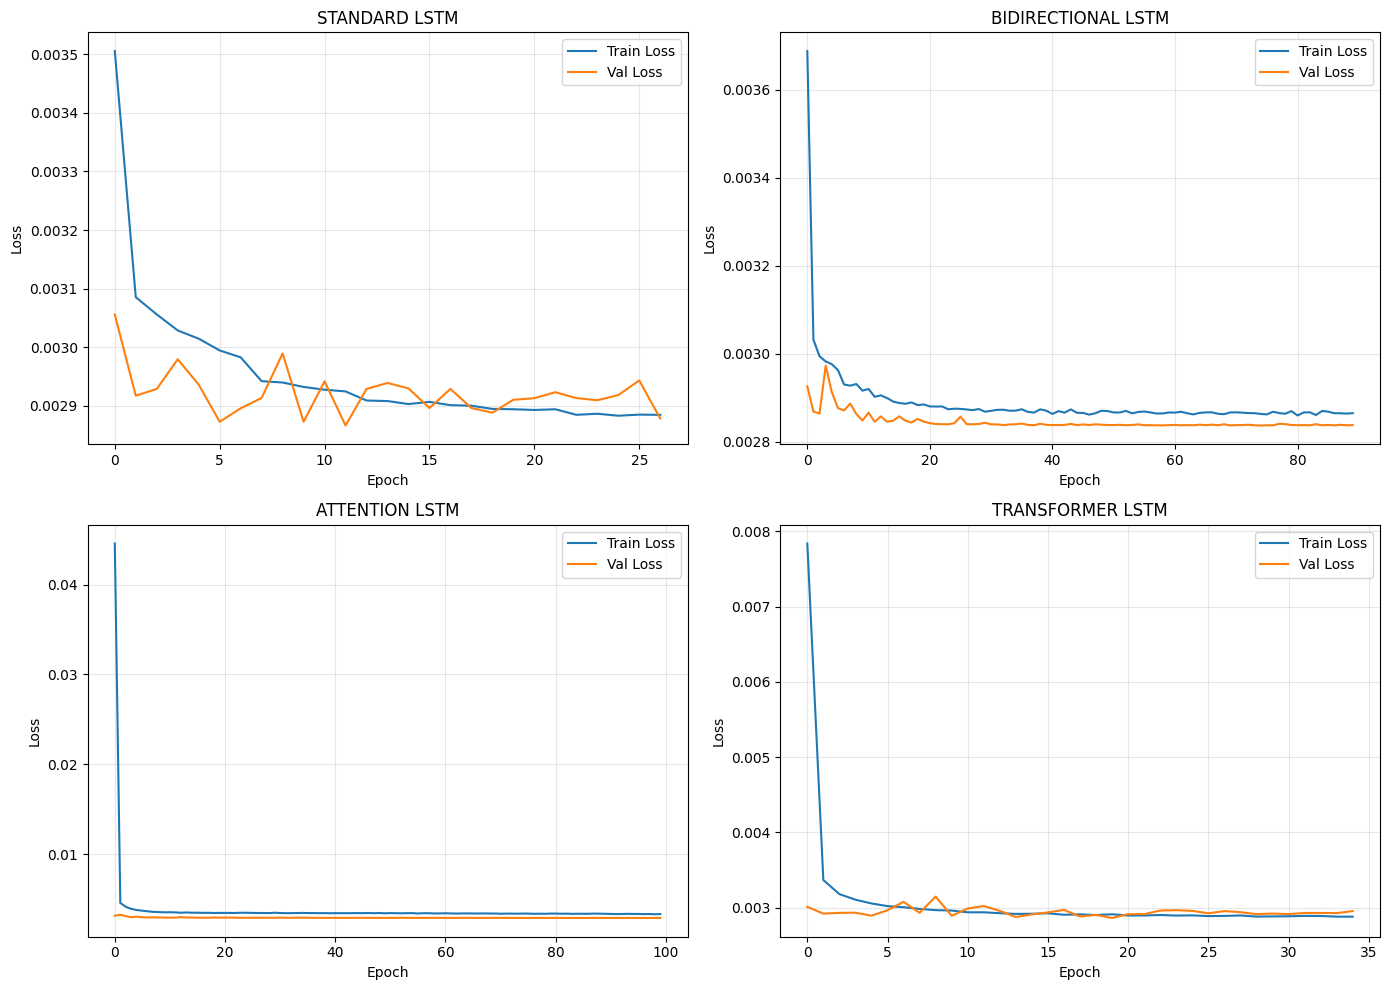

In [20]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx // 2, idx % 2]
    ax.plot(history['loss'], label='Train Loss')
    ax.plot(history['val_loss'], label='Val Loss')
    ax.set_title(f'{name.upper()} LSTM')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/training_history.png', dpi=150)
plt.show()

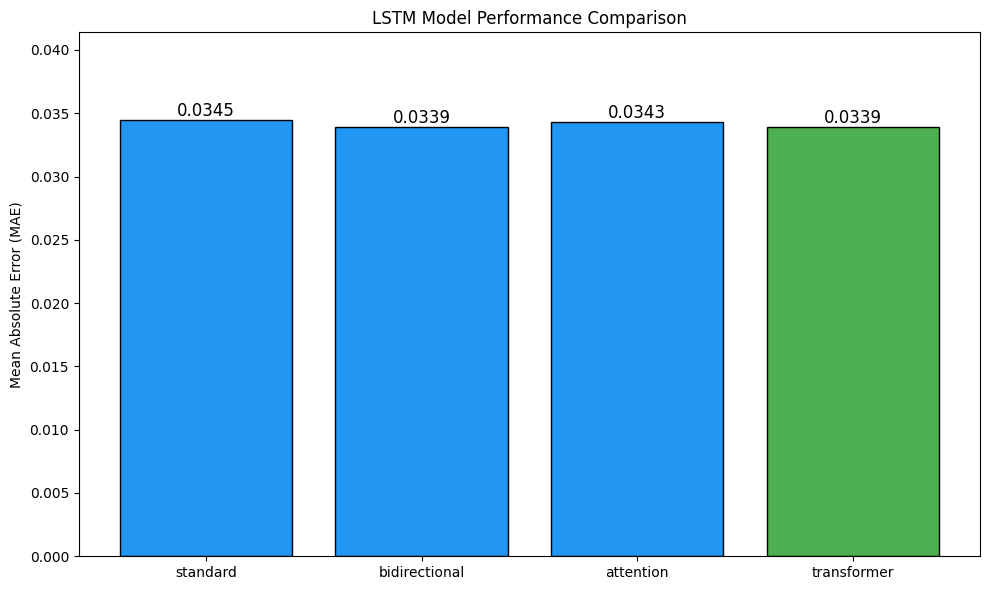

In [21]:
# MAE Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

models = list(results.keys())
maes = [results[m]['mae'] for m in models]
colors = ['#4CAF50' if m == best_model else '#2196F3' for m in models]

bars = ax.bar(models, maes, color=colors, edgecolor='black')
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('LSTM Model Performance Comparison')
ax.set_ylim(0, max(maes) * 1.2)

for bar, mae in zip(bars, maes):
    ax.annotate(f'{mae:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/model_comparison.png', dpi=150)
plt.show()

In [25]:
from tensorflow.keras.models import load_model

# Load bidirectional model
bidirectional_model = load_model(f'{MODEL_PATH}/lstm_bidirectional.keras')

# Evaluate on test set
y_pred_bi = bidirectional_model.predict(X_test)

# Inverse transform to original scale
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_orig = target_scaler.inverse_transform(y_pred_bi).flatten()

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"📊 Bidirectional LSTM Metrics:")
print(f"  MAE: {mae:.2f} vehicles")
print(f"  RMSE: {rmse:.2f} vehicles")
print(f"  R²: {r2:.4f}")



311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
📊 Bidirectional LSTM Metrics:
  MAE: 2.37 vehicles
  RMSE: 3.67 vehicles
  R²: 0.7018


## 7. Test Predictions

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


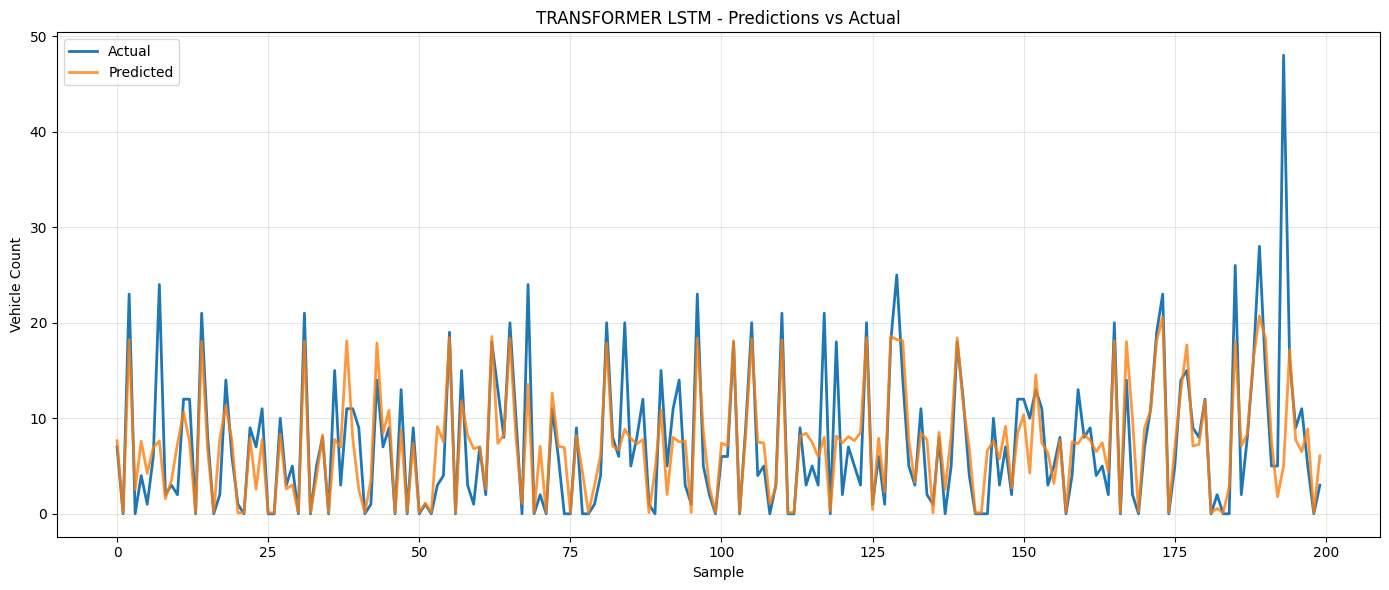


📊 Final Metrics (Original Scale):
  MAE: 2.37 vehicles
  RMSE: 3.68 vehicles
  R²: 0.6994


In [22]:
# Load best model and make predictions
best_model_path = f'{MODEL_PATH}/lstm_{best_model}.keras'
model_best = tf.keras.models.load_model(best_model_path)

# Make predictions on test set
y_pred_scaled = model_best.predict(X_test)

# Inverse transform to get actual values
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 6))

sample_size = min(200, len(y_actual))
ax.plot(y_actual[:sample_size], label='Actual', linewidth=2)
ax.plot(y_pred[:sample_size], label='Predicted', linewidth=2, alpha=0.8)

ax.set_xlabel('Sample')
ax.set_ylabel('Vehicle Count')
ax.set_title(f'{best_model.upper()} LSTM - Predictions vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/predictions_vs_actual.png', dpi=150)
plt.show()

# Calculate metrics in original scale
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n📊 Final Metrics (Original Scale):")
print(f"  MAE: {mae:.2f} vehicles")
print(f"  RMSE: {rmse:.2f} vehicles")
print(f"  R²: {r2:.4f}")

## 8. Save Results & Export for TMS2

In [23]:
# Save training summary
import json

training_summary = {
    'training_date': pd.Timestamp.now().isoformat(),
    'data_shape': {'samples': int(X.shape[0]), 'sequence_length': int(SEQUENCE_LENGTH), 'features': int(N_FEATURES)},
    'train_samples': int(X_train.shape[0]),
    'val_samples': int(X_val.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'epochs_trained': EPOCHS,
    'batch_size': BATCH_SIZE,
    'results': {k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()},
    'best_model': best_model,
    'best_mae': float(results[best_model]['mae'])
}

with open(f'{MODEL_PATH}/training_summary.json', 'w') as f:
    json.dump(training_summary, f, indent=2)

print("✅ Training summary saved!")
print(json.dumps(training_summary, indent=2))

✅ Training summary saved!
{
  "training_date": "2025-12-20T09:30:40.301861",
  "data_shape": {
    "samples": 66243,
    "sequence_length": 15,
    "features": 5
  },
  "train_samples": 46370,
  "val_samples": 9936,
  "test_samples": 9937,
  "epochs_trained": 100,
  "batch_size": 256,
  "results": {
    "standard": {
      "loss": 0.0027859662659466267,
      "mae": 0.034490570425987244
    },
    "bidirectional": {
      "loss": 0.0027469098567962646,
      "mae": 0.03391818702220917
    },
    "attention": {
      "loss": 0.0028117133770138025,
      "mae": 0.03427020087838173
    },
    "transformer": {
      "loss": 0.002769461600109935,
      "mae": 0.03387119621038437
    }
  },
  "best_model": "transformer",
  "best_mae": 0.03387119621038437
}


In [24]:
# Create deployment-ready model (save as .h5 for compatibility)
model_best.save(f'{MODEL_PATH}/lstm_traffic_predictor.h5')

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"\nModels saved to: {MODEL_PATH}")
print("\nFiles created:")
print("  - lstm_standard.keras")
print("  - lstm_bidirectional.keras")
print("  - lstm_attention.keras")
print("  - lstm_transformer.keras")
print("  - lstm_traffic_predictor.h5 (best model for deployment)")
print("  - training_summary.json")
print("  - training_history.png")
print("  - model_comparison.png")
print("  - predictions_vs_actual.png")
print(f"\n🏆 Best Model: {best_model} (MAE: {results[best_model]['mae']:.4f})")
print("\nNext: Open 03_RL_Training.ipynb to train the RL agent!")


✅ TRAINING COMPLETE!

Models saved to: /content/drive/MyDrive/tms2_colab_training/models

Files created:
  - lstm_standard.keras
  - lstm_bidirectional.keras
  - lstm_attention.keras
  - lstm_transformer.keras
  - lstm_traffic_predictor.h5 (best model for deployment)
  - training_summary.json
  - training_history.png
  - model_comparison.png
  - predictions_vs_actual.png

🏆 Best Model: transformer (MAE: 0.0339)

Next: Open 03_RL_Training.ipynb to train the RL agent!


In [ ]:
import shutil
shutil.copy(f'{MODEL_PATH}/lstm_bidirectional.keras',
            f'{MODEL_PATH}/lstm_traffic_predictor.h5')
print("✅ Bidirectional saved as deployment model!")